# Exercise 1

In [26]:
import time
import numpy as np
import matplotlib.pyplot as plt

## Theory

Diffusion limited aggregation (DLA) can be formulated as a boundary-growth problem governed by steady state diffusion. In this picture, the surrounding particles or nutrients diffuse through space toward an already existing cluster, and the concentration field is assumed to relax much faster than the cluster grows. The transport field is therefore modeled by the time-independent diffusion equation, that is, Laplace 's equation,

$$
\nabla^2 c = 0,
$$

where $c$ denotes the concentration of diffusing particles. At each iteration, the Laplace equation is solved in the region outside the cluster subject to appropriate boundary conditions, so that the local concentration near the cluster boundary can be determined.

Growth is restricted to a discrete set of growth candidates, i.e. the sites adjacent to the current cluster where a new particle could attach. Each candidate site $(i,j)$ is assigned a growth probability based on the local concentration $c_{i,j}$. The probability of growth at candidate $(i,j)$ is:
$$
p_g(i,j) = \frac{c_{i,j}^{\eta}}{\sum_{\text{growth candidates}} c_{i,j}^{\eta}}.
$$
This normalization ensures that the probabilities over all candidate sites sum to one. 

A single candidate is then selected according to $p_g$ and added to the cluster. After this growth event, the cluster geometry changes, the diffusion field must be recomputed by solving Laplace's equation again, and the procedure is repeated for many growth steps. In this way, complex branched aggregates emerge from the repeated coupling between diffusion and stochastic attachment.

The parameter $\eta$ controls how strongly growth favors regions of high concentration and therefore determines the overall morphology of the aggregate. For $\eta=1$, the model produces the standard DLA cluster. For $\eta<1$, differences between candidate sites are suppressed, leading to more compact structures; in the limiting case $\eta=0$, all candidates are equally likely and the result approaches Eden-type growth. For $\eta>1$, growth becomes increasingly concentrated at the most exposed tips where the concentration is highest, producing more open, sparse, and highly branched clusters, sometimes akin to lightning-like patterns. 



## Methods

The aggregate was modeled on a two-dimensional square lattice as an iterative Laplacian growth process. The cluster was initialized from a single occupied seed site at the center of the computational domain. Growth then proceeded by repeatedly solving for the steady diffusion field around the existing cluster, identifying all admissible growth sites, assigning a probability of attachment to each such site, and adding one new site to the cluster at each iteration.

\paragraph*{Diffusion field}
At every growth step, the concentration field $c(\mathbf{x})$ in the unoccupied region was assumed to satisfy the time-independent diffusion equation:
$$
\nabla^2 c = 0,
$$
which is Laplace's equation. The occupied cluster acted as an absorbing boundary, so the concentration on all cluster sites was set to zero.

A fixed concentration was imposed at the outer boundary of the simulation domain, maintaining a supply of diffusing material from the far field. Solving this boundary-value problem yielded the concentration at every unoccupied lattice site surrounding the cluster.

\paragraph*{Growth candidates}
After computing the diffusion field, the set of possible attachment sites was determined. A lattice site was considered a growth candidate if it was unoccupied and was a nearest neighbor of at least one occupied cluster site. Thus, if $S_n$ denotes the cluster after $n$ growth steps, the candidate set $G_n$ consisted of all empty sites adjacent to $S_n$. Restricting growth to nearest-neighbor sites ensured that the cluster remained connected throughout the simulation.

\paragraph*{Growth probabilities}
Each candidate site $(i,j)\in G_n$ was assigned a growth probability based on the local concentration $c_{i,j}$. The attachment probability was defined such that:
$$
p_g(i,j)
\frac{c_{i,j}^{\eta}}
{\displaystyle \sum_{(k,\ell)\in G_n} c_{k,\ell}^{\eta}},
$$

where $\eta$ is the model parameter controlling the sensitivity of growth to the concentration field (see Theory). This normalization guarantees:
$$
\sum_{(i,j)\in G_n} p_g(i,j)=1.
$$

The exponent $\eta$ determines how strongly the growth process favors highly exposed sites. For $\eta=1$, the model reduces to standard diffusion-limited aggregation. For $\eta<1$, differences in concentration between candidate sites are suppressed, leading to more compact aggregates. In the limiting case $\eta=0$, all candidates are thus equally likely:
$$
p_g(i,j)=\frac{1}{|G_n|},
$$

which corresponds to the Eden-like growth pattern. For $\eta>1$, growth is increasingly concentrated at sites with the highest concentration, producing more open and highly branched structures.

\paragraph*{Cluster update}
Once the probabilities had been computed, one candidate site was selected randomly according to the discrete distribution $p_g(i,j)$ and added irreversibly to the cluster. If the selected site is denoted by $(i^\ast,j^\ast)$, the cluster update can be written as
$$
S_{n+1} = S_n \cup {(i^\ast,j^\ast)}.
$$

After the new site was added, the geometry of the cluster changed, and the diffusion problem was solved again on the updated domain. This procedure was repeated for a large number of growth steps to generate the final aggregate.

<!-- \paragraph*{Numerical procedure}
The full simulation therefore consisted of the following repeated cycle:
\begin{enumerate}
    \item solve Laplace's equation in the region exterior to the current cluster;
    \item identify all unoccupied nearest-neighbor sites as growth candidates;
    \item evaluate the concentration at each candidate site;
    \item compute normalized attachment probabilities using $p_g \propto c^\eta$;
    \item select one candidate stochastically and attach it to the cluster.
\end{enumerate} -->

In [21]:
def initial_linear_field(shape, c_bottom=0.0, c_top=1.0):
    ny, nx = shape
    y = np.linspace(c_bottom, c_top, ny)[:, None]
    return np.repeat(y, nx, axis=1)

def solve_laplace(cluster, c_bottom=0.0, c_top=1.0, max_iter=20_000, tol=1e-5):
    ny, nx = cluster.shape
    c = initial_linear_field((ny, nx), c_bottom=c_bottom, c_top=c_top)
    c[cluster] = 0.0

    for _ in range(max_iter):
        c_old = c.copy()
        c[1:-1, 1:-1] = 0.25 * (
            c_old[:-2, 1:-1] +
            c_old[2:, 1:-1] +
            c_old[1:-1, :-2] +
            c_old[1:-1, 2:]
        )

        c[cluster] = 0.0
        c[0, :] = c_bottom
        c[-1, :] = c_top
        c[:, 0] = c[:, 1]
        c[:, -1] = c[:, -2]

        err = np.max(np.abs(c - c_old))
        if err < tol:
            break

    return c


def find_growth_candidates(cluster, margin=1):
    ny, nx = cluster.shape
    candidates = set()
    occupied = np.argwhere(cluster)

    for i, j in occupied:
        for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            ni, nj = i + di, j + dj
            if margin <= ni < ny - margin and margin <= nj < nx - margin and not cluster[ni, nj]:
                candidates.add((ni, nj))

    if not candidates:
        return np.empty((0, 2), dtype=int)

    return np.array(list(candidates), dtype=int)


def compute_growth_probabilities(concentration, candidates, eta=1.0, eps=1e-15):
    """
    concentration : steady concentration field
    candidates : candidate lattice sites
    eta : morphology parameter
    """
    ci = concentration[candidates[:, 0], candidates[:, 1]]

    if np.isclose(eta, 0.0):
        weights = np.ones_like(ci, dtype=float)
    else:
        ci = np.maximum(ci, 0.0)
        weights = np.power(ci + eps, eta)

    total = weights.sum()
    probs = weights / total
    return probs, weights


def grow_cluster(
    size: int = 101,
    steps: int = 500,
    eta: float = 1.0,
    c_bottom: float = 0.0,
    c_top: float = 1.0,
    margin: int = 0,
):
    rng = np.random.default_rng()
    cluster = np.zeros((size, size), dtype=bool)
    seed_site = (1, size // 2)
    cluster[seed_site] = True
    history = []

    for step in range(steps):
        concentration = solve_laplace(
            cluster,
            c_bottom=c_bottom,
            c_top=c_top,
        )
        candidates = find_growth_candidates(cluster, margin=margin)

        if len(candidates) == 0:
            break

        probs, weights = compute_growth_probabilities(
            concentration,
            candidates,
            eta=eta,
        )

        chosen_idx = rng.choice(len(candidates), p=probs)
        i, j = candidates[chosen_idx]
        cluster[i, j] = True

        history.append({
            "step": step,
            "num_candidates": len(candidates),
            "chosen_site": (int(i), int(j)),
            "chosen_probability": float(probs[chosen_idx]),
            "max_candidate_concentration": float(concentration[candidates[:, 0], candidates[:, 1]].max()),
            "probabilities": probs.copy(),
            "candidates": candidates.copy(),
            "weights": weights.copy(),
        })

    return cluster, history

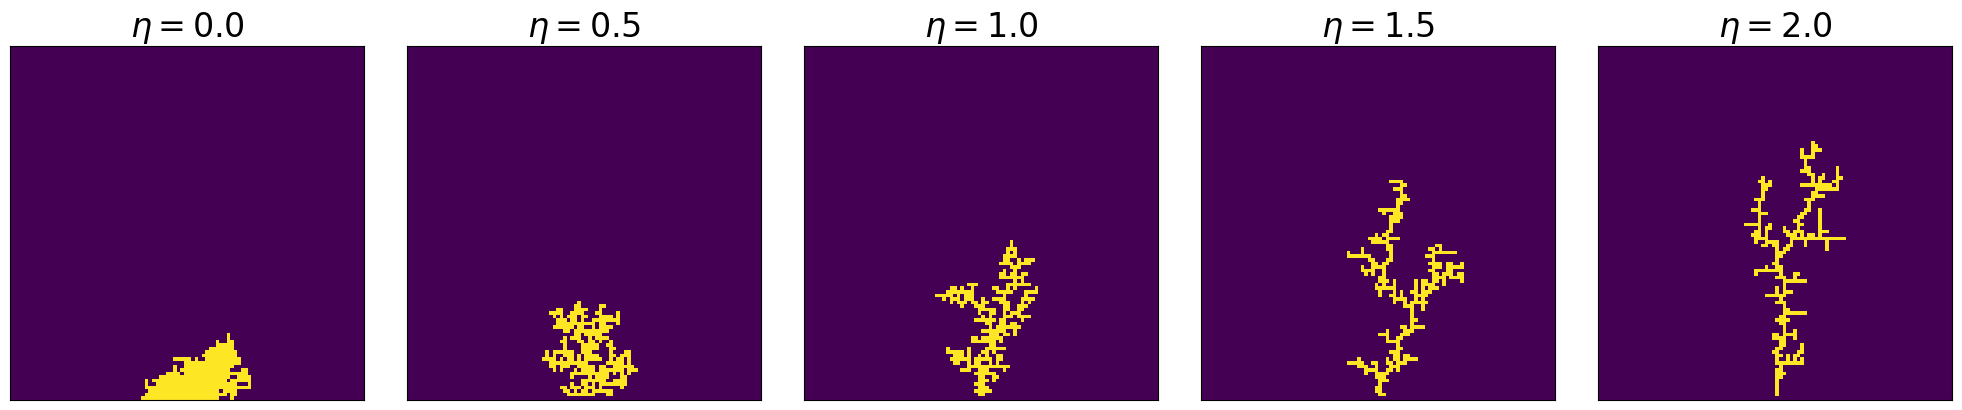

In [22]:
# Ex 1.A:
etas = [0.0, 0.5, 1.0, 1.5, 2.0]
n_runs_per_eta = 1
size = 100
steps = 300
boundary_value = 1.0

all_results = {}

for eta in etas:
    runs = []
    for run_idx in range(n_runs_per_eta):
        cluster, history = grow_cluster(
            size=size,
            steps=steps,
            eta=eta,
            # boundary_value=boundary_value,
        )
        runs.append({
            "cluster": cluster,
            "history": history,
            "mass": int(cluster.sum()),
        })
    all_results[eta] = runs

# Plot one representative cluster for each eta
fig, axes = plt.subplots(1, 5, figsize=(4 * 5, 4))

for ax, eta in zip(axes, etas):
    cluster = all_results[eta][0]["cluster"]  # first run for this eta
    ax.imshow(cluster, origin="lower", interpolation="nearest")
    ax.set_title(f"$\\eta = {eta}$", fontsize=24)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

### Red-Black SOR

In [15]:
def initial_linear_field(shape, c_bottom=0.0, c_top=1.0):
    ny, nx = shape
    y = np.linspace(c_bottom, c_top, ny)[:, None]
    return np.repeat(y, nx, axis=1)


def make_checkerboard_masks(shape):
    ny, nx = shape
    ii, jj = np.indices((ny, nx))
    red = ((ii + jj) % 2 == 0)
    black = ~red

    interior = np.zeros((ny, nx), dtype=bool)
    interior[1:-1, 1:-1] = True

    return red & interior, black & interior


def apply_boundary_conditions(c, cluster, c_bottom, c_top):
    c[cluster] = 0.0
    c[0, :] = c_bottom
    c[-1, :] = c_top
    c[:, 0] = c[:, 1]
    c[:, -1] = c[:, -2]


def sor_red_black_laplace(
    cluster,
    c_init=None,
    c_bottom=0.0,
    c_top=1.0,
    omega=None,
    tol=1e-5,
    max_iter=10000,
    red_mask=None,
    black_mask=None,
):
    ny, nx = cluster.shape
    N = max(ny, nx)

    if omega is None:
        omega = 2.0 / (1.0 + np.sin(np.pi / N))

    if c_init is None:
        c = initial_linear_field((ny, nx), c_bottom=c_bottom, c_top=c_top)
    else:
        c = c_init.copy()

    if red_mask is None or black_mask is None:
        red_mask, black_mask = make_checkerboard_masks((ny, nx))

    active_red = red_mask & (~cluster)
    active_black = black_mask & (~cluster)

    apply_boundary_conditions(c, cluster, c_bottom, c_top)

    for it in range(1, max_iter + 1):
        max_update = 0.0
        avg = 0.25 * (
            np.roll(c, 1, axis=0) + np.roll(c, -1, axis=0) +
            np.roll(c, 1, axis=1) + np.roll(c, -1, axis=1)
        )

        # red half
        old_red = c[active_red].copy()
        c[active_red] = (1.0 - omega) * c[active_red] + omega * avg[active_red]
        if old_red.size:
            max_update = max(max_update, np.max(np.abs(c[active_red] - old_red)))

        apply_boundary_conditions(c, cluster, c_bottom, c_top)

        avg = 0.25 * (
            np.roll(c, 1, axis=0) + np.roll(c, -1, axis=0) +
            np.roll(c, 1, axis=1) + np.roll(c, -1, axis=1)
        )

        # black half
        old_black = c[active_black].copy()
        c[active_black] = (1.0 - omega) * c[active_black] + omega * avg[active_black]
        if old_black.size:
            max_update = max(max_update, np.max(np.abs(c[active_black] - old_black)))

        apply_boundary_conditions(c, cluster, c_bottom, c_top)

        if max_update < tol:
            break

    return c, it, omega


def find_growth_candidates(cluster):
    ny, nx = cluster.shape
    candidates = set()
    occupied = np.argwhere(cluster)

    for i, j in occupied:
        for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            ni, nj = i + di, j + dj
            if 0 <= ni < ny and 0 <= nj < nx and not cluster[ni, nj]:
                candidates.add((ni, nj))

    if not candidates:
        return np.empty((0, 2), dtype=int)

    return np.array(list(candidates), dtype=int)


def growth_probabilities(concentration, candidates, eta, eps=1e-15):
    ci = concentration[candidates[:, 0], candidates[:, 1]]
    ci = np.maximum(ci, 0.0)

    if np.isclose(eta, 0.0):
        weights = np.ones_like(ci, dtype=float)
    else:
        weights = np.power(ci + eps, eta)

    s = weights.sum()
    if not np.isfinite(s) or s <= 0:
        raise ValueError("Growth weights sum to zero.")

    return weights / s


def grow_cluster_red_black_sor(
    size=100,
    steps=500,
    eta=1.0,
    c_bottom=0.0,
    c_top=1.0,
    omega=None,
    tol=1e-5,
    max_iter=10000,
    seed=0,
):
    rng = np.random.default_rng(seed)
    cluster = np.zeros((size, size), dtype=bool)
    seed = (1, size // 2)
    cluster[seed] = True

    red_mask, black_mask = make_checkerboard_masks((size, size))

    c_prev = initial_linear_field((size, size), c_bottom=c_bottom, c_top=c_top)
    c_prev[cluster] = 0.0

    iter_counts = []
    masses = [int(cluster.sum())]

    for step in range(steps):
        c, n_iter, omega_used = sor_red_black_laplace(
            cluster,
            c_init=c_prev,
            c_bottom=c_bottom,
            c_top=c_top,
            omega=omega,
            tol=tol,
            max_iter=max_iter,
            red_mask=red_mask,
            black_mask=black_mask,
        )

        candidates = find_growth_candidates(cluster)
        if len(candidates) == 0:
            break

        probs = growth_probabilities(c, candidates, eta)
        chosen = rng.choice(len(candidates), p=probs)
        i, j = candidates[chosen]
        cluster[i, j] = True

        c_prev = c
        c_prev[i, j] = 0.0

        iter_counts.append(n_iter)
        masses.append(int(cluster.sum()))

    diagnostics = {
        "omega": omega_used,
        "mean_sor_iterations": float(np.mean(iter_counts)) if iter_counts else 0.0,
        "max_sor_iterations": int(np.max(iter_counts)) if iter_counts else 0,
        "iterations_per_step": iter_counts,
        "mass_history": masses,
    }

    return cluster, c_prev, diagnostics

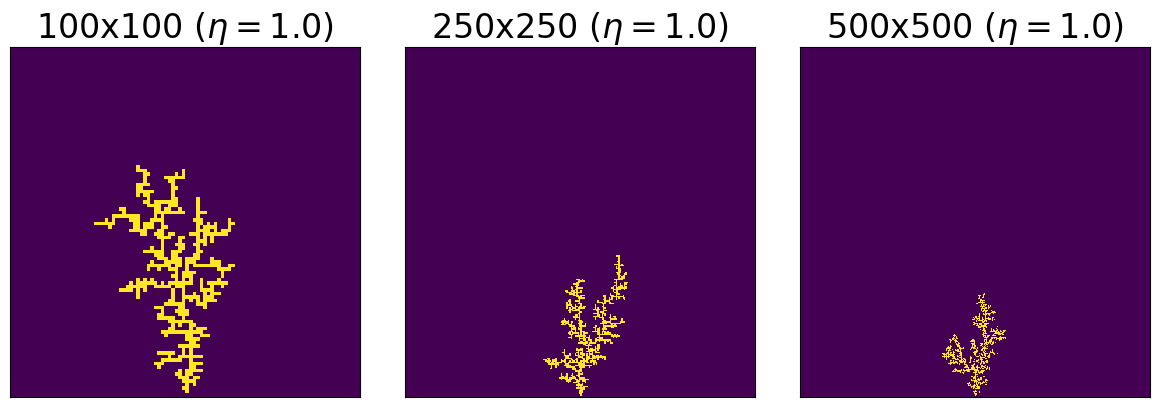

In [36]:
# Ex 1.B: optimized red-black SOR version
eta = 1.0
n_runs_per_eta = 1
sizes = [100, 250, 500]
steps = [500, 1000, 2000]
c_bottom = 0.0
c_top = 1.0

all_results_rb = {}
i = 0
for size in sizes:
    runs = []
    for run_idx in range(n_runs_per_eta):
        cluster, concentration, diagnostics = grow_cluster_red_black_sor(
            size=size,
            steps=steps[i],
            eta=eta,
            c_bottom=c_bottom,
            c_top=c_top,
            omega=None,
            tol=1e-4,
            max_iter=500,
            seed=2000 + run_idx,
        )
        runs.append({
            "cluster": cluster,
            "concentration": concentration,
            "diagnostics": diagnostics,
            "mass": int(cluster.sum()),
        })
    all_results_rb[size] = runs
    i += 1

# Plot one representative cluster for each eta
fig, axes = plt.subplots(1, 3, figsize=(4 * 3, 4))

for ax, size in zip(axes, sizes):
    cluster = all_results_rb[size][0]["cluster"]
    ax.imshow(cluster, origin="lower", interpolation="nearest")
    ax.set_title(f"{size}x{size} ($\\eta = {eta}$)", fontsize=24)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

### Benchmarks

In [30]:
etas = [0.0, 0.5, 1.0, 1.5, 2.0]
n_runs_per_eta = 1
size = 100
steps = 500

methods = {
    "Original": lambda eta, seed: grow_cluster(
        size=size,
        steps=steps,
        eta=eta,
        # boundary_value=1.0,
        # rng=np.random.default_rng(seed),
    ),
    "RB-SOR": lambda eta, seed: grow_cluster_red_black_sor(
        size=size,
        steps=steps,
        eta=eta,
        c_bottom=0.0,
        c_top=1.0,
        omega=None,
        tol=1e-5,
        max_iter=5000,
        seed=seed,
    ),
}

timing_results = {method: {eta: [] for eta in etas} for method in methods}

for method_name, method_func in methods.items():
    for eta in etas:
        for run_idx in range(n_runs_per_eta):
            seed = 1000 + run_idx

            t0 = time.perf_counter()
            _ = method_func(eta, seed)
            t1 = time.perf_counter()

            timing_results[method_name][eta].append(t1 - t0)

# Print summary
for method_name in methods:
    print(f"\n{method_name}")
    for eta in etas:
        times = timing_results[method_name][eta]
        print(
            f"  eta={eta:.1f}: "
            f"mean={np.mean(times):.3f} s, "
            f"std={np.std(times):.3f} s, "
            f"min={np.min(times):.3f} s, "
            f"max={np.max(times):.3f} s"
        )


Original
  eta=0.0: mean=22.080 s, std=0.000 s, min=22.080 s, max=22.080 s
  eta=0.5: mean=35.151 s, std=0.000 s, min=35.151 s, max=35.151 s
  eta=1.0: mean=48.799 s, std=0.000 s, min=48.799 s, max=48.799 s
  eta=1.5: mean=52.627 s, std=0.000 s, min=52.627 s, max=52.627 s
  eta=2.0: mean=61.395 s, std=0.000 s, min=61.395 s, max=61.395 s

RB-SOR
  eta=0.0: mean=7.287 s, std=0.000 s, min=7.287 s, max=7.287 s
  eta=0.5: mean=9.307 s, std=0.000 s, min=9.307 s, max=9.307 s
  eta=1.0: mean=11.038 s, std=0.000 s, min=11.038 s, max=11.038 s
  eta=1.5: mean=12.536 s, std=0.000 s, min=12.536 s, max=12.536 s
  eta=2.0: mean=12.742 s, std=0.000 s, min=12.742 s, max=12.742 s


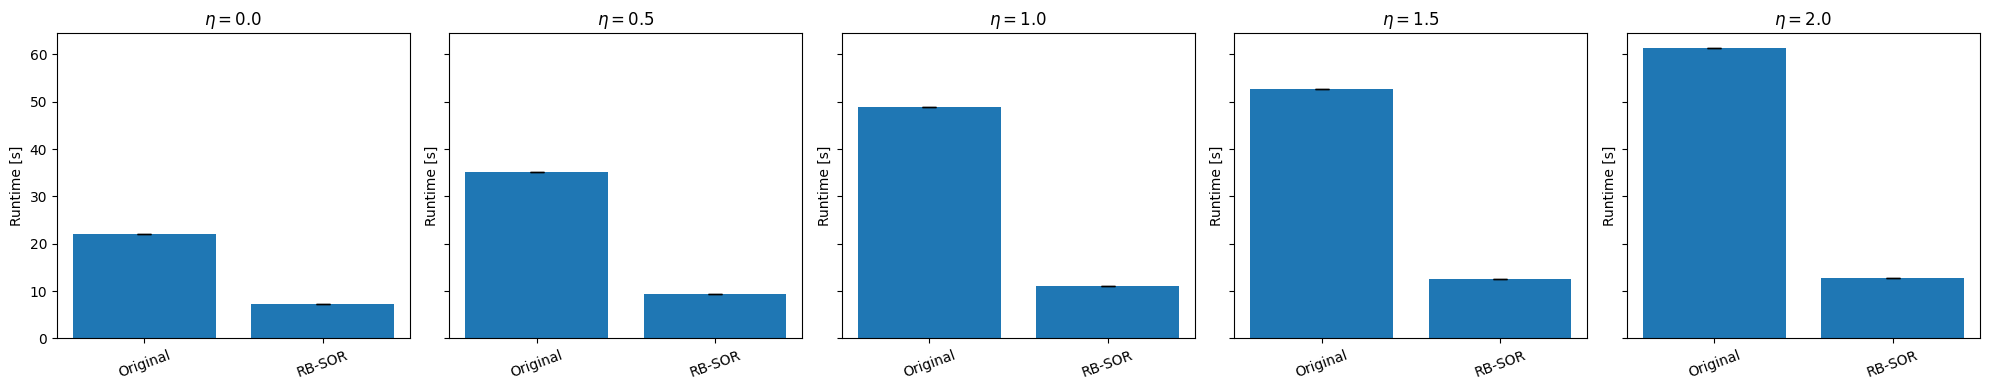

In [31]:
fig, axes = plt.subplots(1, len(etas), figsize=(4 * len(etas), 4), sharey=True)

for ax, eta in zip(axes, etas):
    labels = []
    means = []
    stds = []

    for method_name in methods:
        times = timing_results[method_name][eta]
        labels.append(method_name)
        means.append(np.mean(times))
        stds.append(np.std(times))

    ax.bar(labels, means, yerr=stds, capsize=5)
    ax.set_title(f"$\\eta = {eta}$")
    ax.set_ylabel("Runtime [s]")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

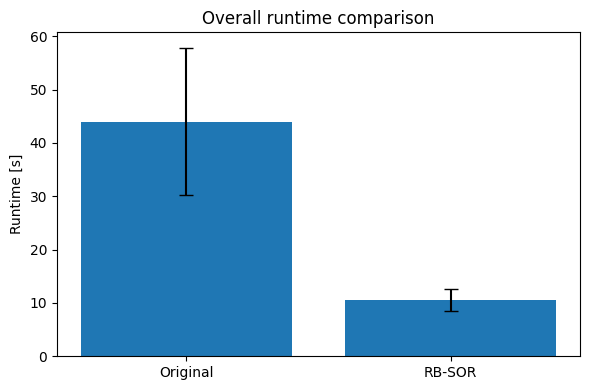

In [32]:
overall_means = []
overall_stds = []
labels = []

for method_name in methods:
    all_times = []
    for eta in etas:
        all_times.extend(timing_results[method_name][eta])

    labels.append(method_name)
    overall_means.append(np.mean(all_times))
    overall_stds.append(np.std(all_times))

plt.figure(figsize=(6, 4))
plt.bar(labels, overall_means, yerr=overall_stds, capsize=5)
plt.ylabel("Runtime [s]")
plt.title("Overall runtime comparison")
plt.tight_layout()
plt.show()

## Conclusion

In conclusion, the diffusion-limited growth model reproduced the expected dependence of cluster morphology on the parameter $\eta$: lower values led to more compact aggregates, whereas larger values increasingly favored tip growth and produced more open, branched structures. To reduce the computational cost of repeatedly solving Laplace's equation during growth, the standard SOR scheme was reformulated as a red-black SOR iteration. In this approach, the lattice is partitioned into two checkerboard sublattices, so that all red sites can be updated using the current black values, followed by an update of all black sites using the new red values. This preserves the accelerated convergence properties of SOR while making the update pattern more structured and more suitable for vectorized or parallel execution.

The question of whether one can still optimize by choosing a specific relaxation parameter $\omega$ must be answered with some nuance. In principle, yes: for a fixed grid there is still a near-optimal value of $\omega$ that minimizes the number of iterations needed for convergence. However, in the present problem this optimization is no longer the dominant one. Because the cluster grows only by one lattice site at a time, the concentration field changes only slightly from one growth step to the next. As a result, the most effective improvement is to use the converged solution from the previous growth step as the initial guess for the next SOR solve. Likewise, at the beginning of the simulation, the empty-domain analytical solution given by the linear concentration gradient provides an excellent initial condition. These warm starts reduce the number of required iterations substantially, so that the exact tuning of $\omega$ becomes less critical than it would be for a cold start from an arbitrary field. Thus, $\omega$ can still be optimized and does still influence performance, but the main speedup comes from reusing previously converged concentration fields together with the structured red-black SOR update.